In [1]:
import sys
import os
import pandas as pd

sys.path.append('../src/scripts')
sys.path.append('../src/classes')
from simulation import Simulation
from config import get_simulation_number
from data_scraping_in_results import scraper

In [2]:
mobility_file_path = '../src/sumo/csv/train_single.csv'
edge_file_path = '../src/inputs/train/edge_servers.json'
vehicle_file_path = '../src/inputs/train/vehicles_single.json'


In [3]:
_proposed="proposed"
_local= "local_only"
_offload = "offload_only"
_random = "random"
algorithms = [_proposed,_local,_offload,_random]
simulation_number = "trainset"
report_paths = {}

for a in algorithms:
    report_paths[a] = ('../results/reports/'+str(simulation_number)+'_report_'+a+'_test.csv')
q_table_path = '../results/q_table/'+str(simulation_number)+'_q_table_proposed'

#overwrite specific report addresses for proposed
proposed_test_sim_number=99
proposed_test_number='train'
if(proposed_test_number != 'train'):
    report_paths[_proposed]='../results/reports/'+str(proposed_test_sim_number)+'_report_'+_proposed+'_test_'+str(proposed_test_number)+'.csv'
else:
    report_paths[_proposed]='../results/reports/'+str(proposed_test_sim_number)+'_report_'+_proposed+'_train.csv'


num_of_cars=20
end_time_limit=100000
# should_update_q_table = False
print(report_paths)

{'proposed': '../results/reports/99_report_proposed_train.csv', 'local_only': '../results/reports/trainset_report_local_only_test.csv', 'offload_only': '../results/reports/trainset_report_offload_only_test.csv', 'random': '../results/reports/trainset_report_random_test.csv'}


In [4]:
scrapers={}
for a in algorithms:
    scrapers[a] = scraper(report_paths[a],num_of_cars,end_time_limit)

---------------------------------------------
../results/reports/99_report_proposed_train.csv
The time limit is: 100000
Header --->
   vehicle_id  task_id  execution_location      size    distance  \
0           1        1                   0   2000000  180.123622   
1           1        2                   1   9000000  178.219525   
2           1        4                   1   7000000  174.280050   
3           1        3                   0   8000000  183.890262   
4           1        7                   1  10000000  115.758481   

   transfer_rate  execution_cycles  start_time  end_time  release_time  \
0   0.000000e+00        9000000000           1      9001             1   
1   1.328372e+06        9000000000       11581     13381          3001   
2   1.451372e+06        2000000000       16181     16581          9001   
3   0.000000e+00       10000000000        9001     19001          6001   
4   7.164545e+06        2000000000       19397     19797         18001   

   response_ti

In [5]:
averages = {}
for a in algorithms:
    print("=========================================")
    print(a,"------->")
    averages[a] = scrapers[a].calc_average_all(False)

final_df = pd.concat(averages, names=['Algorithm'])
print(final_df)



proposed ------->
local_only ------->
offload_only ------->
random ------->
Algorithm                  
proposed      response_time    10303.544041
              total_energy         0.993147
local_only    response_time    28847.619048
              total_energy         0.609841
offload_only  response_time    13274.446939
              total_energy         1.164453
random        response_time    10276.949827
              total_energy         0.903553
dtype: float64


In [6]:
for a in algorithms:
    print("=========================================")
    print(a,"----------AVERAGED----->")
    scrapers[a].calc_average_for_each_car()

proposed ----------AVERAGED----->
            response_time  transmission_time  execution_time  \
vehicle_id                                                     
1            10596.413793        2365.000000     3848.275862   
2             5983.333333        1902.666667     3006.666667   
3             9675.566667        3038.466667     3673.333333   
4            14477.413793        3406.344828     3558.620690   
5             9155.400000        4147.400000     2273.333333   
6            13754.928571        4217.357143     3985.714286   
7             8995.379310        2643.793103     3179.310345   
8             9879.080000         893.160000     3808.000000   
9            12455.777778        2741.666667     3962.962963   
10            9572.322581         759.677419     3600.000000   
11            8680.166667         695.166667     2940.000000   
12           13004.785714        2839.785714     4021.428571   
13            7100.703704        2909.259259     3029.629630   
14    

In [7]:
for a in algorithms:
    print("=========================================")
    print(a,"----TOTAL------->")
    scrapers[a].calc_sum_for_each_car()

proposed ----TOTAL------->
            response_time  transmission_time  execution_time  \
vehicle_id                                                     
1                  307296              68585          111600   
2                  179500              57080           90200   
3                  290267              91154          110200   
4                  419845              98784          103200   
5                  274662             124422           68200   
6                  385138             118086          111600   
7                  260866              76670           92200   
8                  246977              22329           95200   
9                  336306              74025          107000   
10                 296742              23550          111600   
11                 260405              20855           88200   
12                 364134              79514          112600   
13                 191719              78550           81800   
14           

proposed -------AVERAGE----->
          response_time  transmission_time  execution_time  execution_energy  \
end_time                                                                       
1283             1282.0              882.0           400.0               0.0   
2001             2000.0                0.0          2000.0               0.2   
2640             2639.0              839.0          1800.0               0.0   
2877             2876.0             1476.0          1400.0               0.0   
3001             3000.0                0.0          3000.0               0.3   
...                 ...                ...             ...               ...   
99151            6150.0             1010.0          1400.0               0.0   
99394            3393.0             1540.0           800.0               0.0   
99510            3509.0              512.0          1600.0               0.0   
99752            6751.0             5151.0          1600.0               0.0   
99910     

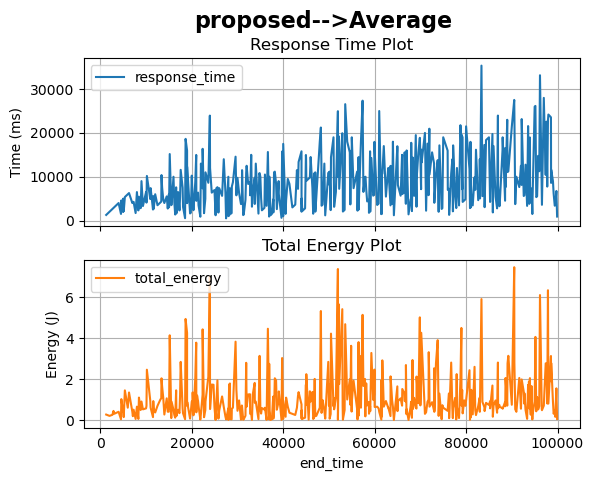

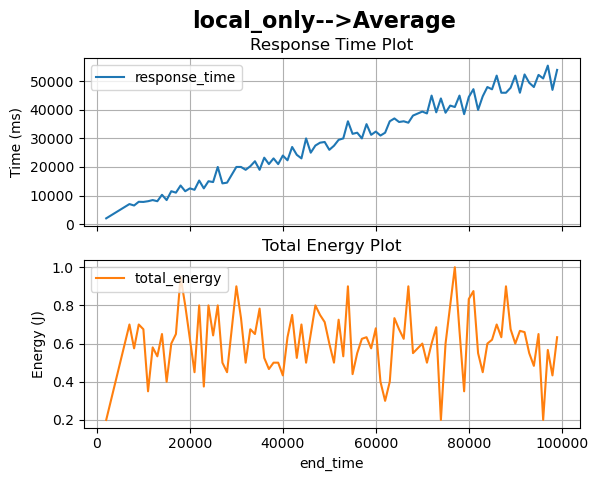

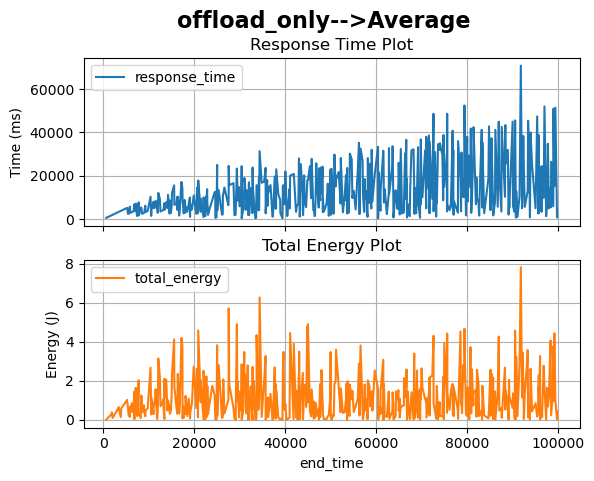

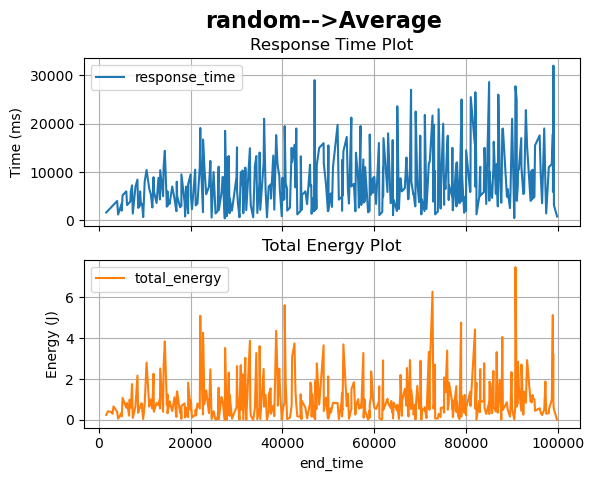

In [8]:
for a in algorithms:
    print("=========================================")
    print(a,"-------AVERAGE----->")
    scrapers[a].calc_average_for_each_end_time(plot=True,plot_title=a+"-->"+"Average")

proposed -------SUM----->
          response_time  transmission_time  execution_time  execution_energy  \
end_time                                                                       
1283               1282                882             400               0.0   
2001               2000                  0            2000               0.2   
2640               2639                839            1800               0.0   
2877               2876               1476            1400               0.0   
3001               3000                  0            3000               0.3   
...                 ...                ...             ...               ...   
99151              6150               1010            1400               0.0   
99394              3393               1540             800               0.0   
99510              3509                512            1600               0.0   
99752              6751               5151            1600               0.0   
99910         

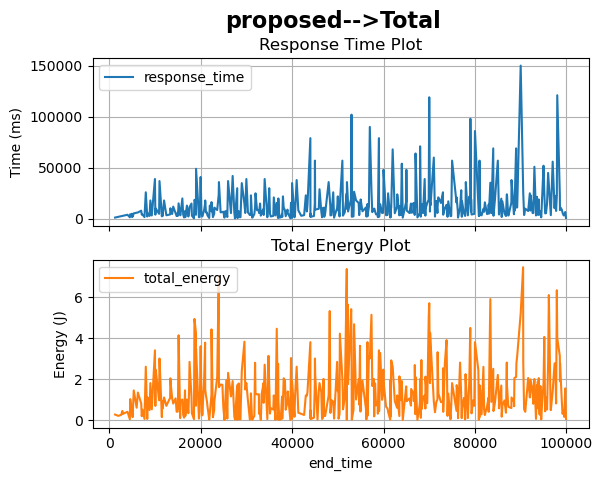

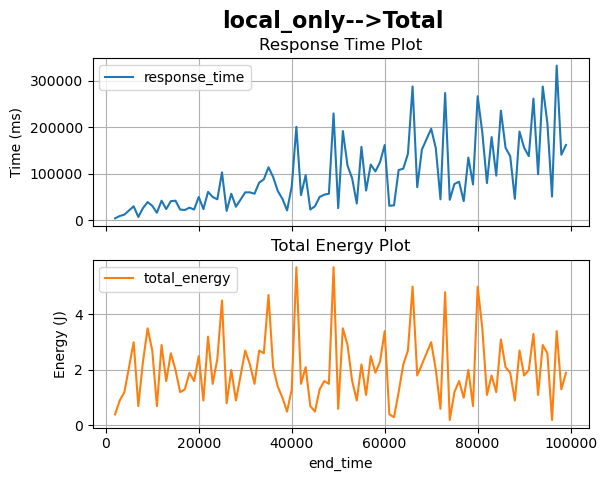

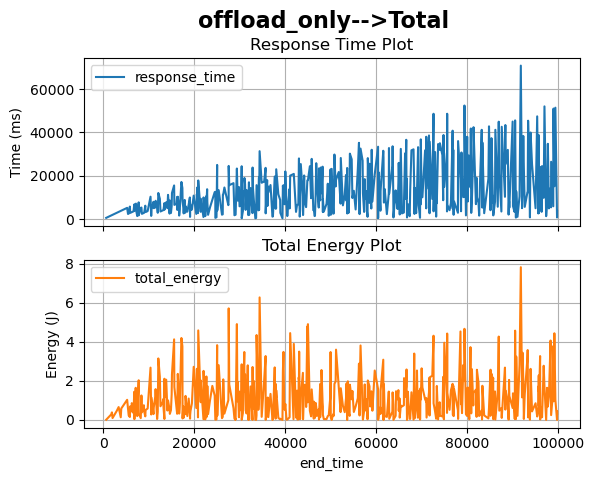

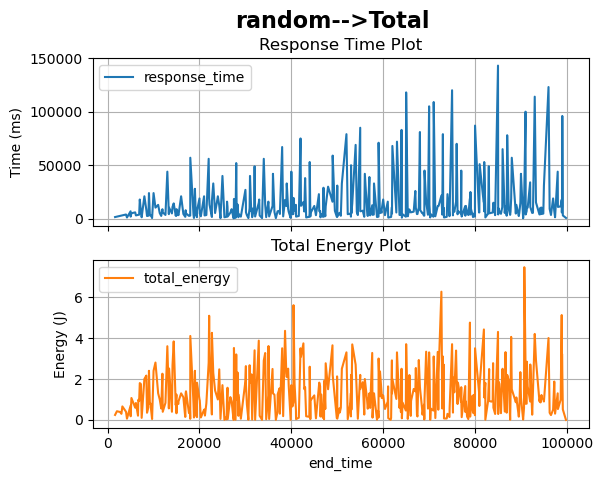

In [9]:
for a in algorithms:
    print("=========================================")
    print(a,"-------SUM----->")
    scrapers[a].calc_sum_for_each_end_time(plot=True,plot_title=a+"-->"+"Total")